<a href="https://colab.research.google.com/github/vishhhsurya/Data-science/blob/main/Aviation_Aircraft_Utilisation_Analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AVIATION — IS THE AIRLINE USING ITS AIRCRAFT EFFICIENTLY?

**Industry:** Aviation

### Objective
Analyse aircraft utilisation, passenger load factor, route occupancy, aircraft-type performance and inefficient route-aircraft combinations.

### Required Machine Learning Algorithm
**Linear Regression**

### Expected Output
- 5–7 key insights
- 4 visualisations
- 1 trained Linear Regression model
- Model evaluation results
- Practical action plan

**Dataset:** Synthetic aviation flight dataset created for this academic assignment.


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 2. Load Dataset

In [2]:
# In Google Colab, upload the CSV file supplied with this project.
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

df.head()


Saving aviation_aircraft_utilisation_data.csv to aviation_aircraft_utilisation_data.csv


,Flight_ID,Aircraft_Type,Route,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers
0,FL1001,Boeing 737,Mumbai-Bengaluru,1.74,0.68,840,174,117
1,FL1002,Airbus A321,Delhi-Kolkata,2.31,0.73,1305,220,167
2,FL1003,Embraer E190,Chennai-Mumbai,1.94,0.67,1030,100,80
3,FL1004,Boeing 737,Chennai-Bengaluru,0.71,0.71,290,174,102
4,FL1005,Airbus A320,Chennai-Delhi,2.80,0.76,1760,180,128


## 3. Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


Dataset Shape: (180, 8)

Columns:
['Flight_ID', 'Aircraft_Type', 'Route', 'Flight_Duration', 'Turnaround_Time', 'Route_Distance', 'Passenger_Capacity', 'Actual_Passengers']

Data Types:
Flight_ID              object
Aircraft_Type          object
Route                  object
Flight_Duration       float64
Turnaround_Time       float64
Route_Distance          int64
Passenger_Capacity      int64
Actual_Passengers       int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Flight_ID           180 non-null    object 
 1   Aircraft_Type       180 non-null    object 
 2   Route               180 non-null    object 
 3   Flight_Duration     180 non-null    float64
 4   Turnaround_Time     180 non-null    float64
 5   Route_Distance      180 non-null    int64  
 6   Passenger_Capacity  180 non-null    i

## 4. Data Cleaning and Validation

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
Flight_ID             0
Aircraft_Type         0
Route                 0
Flight_Duration       0
Turnaround_Time       0
Route_Distance        0
Passenger_Capacity    0
Actual_Passengers     0
dtype: int64

Duplicate rows: 0


In [6]:
df = df.drop_duplicates().copy()

numeric_columns = [
    'Flight_Duration',
    'Turnaround_Time',
    'Route_Distance',
    'Passenger_Capacity',
    'Actual_Passengers'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(
    subset=numeric_columns + ['Flight_ID', 'Aircraft_Type', 'Route']
)

invalid_passengers = df[
    df['Actual_Passengers'] > df['Passenger_Capacity']
]

print("Rows with passengers greater than capacity:", len(invalid_passengers))
print("Final dataset shape:", df.shape)


Rows with passengers greater than capacity: 0
Final dataset shape: (180, 8)


## 5. Feature Engineering

### Passenger Load Factor
Passenger Load Factor measures the percentage of available seats occupied by passengers.

### Operational Metrics
**Total Operation Time = Flight Duration + Turnaround Time**

**Flight Time Ratio = Flight Duration / Total Operation Time × 100**


In [7]:
df['Load_Factor'] = (
    df['Actual_Passengers'] / df['Passenger_Capacity']
) * 100

df['Total_Operation_Time'] = (
    df['Flight_Duration'] + df['Turnaround_Time']
)

df['Flight_Time_Ratio'] = (
    df['Flight_Duration'] / df['Total_Operation_Time']
) * 100

df[['Flight_ID', 'Aircraft_Type', 'Route',
    'Load_Factor', 'Total_Operation_Time',
    'Flight_Time_Ratio']].head()


,Flight_ID,Aircraft_Type,Route,Load_Factor,Total_Operation_Time,Flight_Time_Ratio
0,FL1001,Boeing 737,Mumbai-Bengaluru,67.241379,2.42,71.900826
1,FL1002,Airbus A321,Delhi-Kolkata,75.909091,3.04,75.986842
2,FL1003,Embraer E190,Chennai-Mumbai,80.000000,2.61,74.329502
3,FL1004,Boeing 737,Chennai-Bengaluru,58.620690,1.42,50.000000
4,FL1005,Airbus A320,Chennai-Delhi,71.111111,3.56,78.651685


## 6. Descriptive Statistics

In [8]:
df.describe().round(2)

,Flight_Duration,Turnaround_Time,Route_Distance,Passenger_Capacity,Actual_Passengers,Load_Factor,Total_Operation_Time,Flight_Time_Ratio
count,180.00,180.00,180.00,180.00,180.00,180.00,180.00,180.00
mean,1.89,0.67,1002.03,172.31,122.01,71.62,2.56,72.49
std,0.58,0.11,432.03,37.32,30.14,12.43,0.61,7.39
min,0.70,0.45,290.00,100.00,59.00,40.80,1.27,45.45
25%,1.33,0.59,730.00,174.00,97.75,61.94,2.08,68.70
50%,2.01,0.66,1030.00,174.00,125.00,73.56,2.64,74.22
75%,2.25,0.74,1305.00,180.00,143.00,80.56,2.95,77.55
max,3.07,1.06,1760.00,220.00,196.00,98.28,3.97,86.61


## 7. Overall Utilisation Summary

In [9]:
overall_summary = pd.DataFrame({
    'Metric': [
        'Total Flights',
        'Average Load Factor (%)',
        'Average Flight Duration',
        'Average Turnaround Time',
        'Average Route Distance',
        'Average Passenger Capacity',
        'Average Actual Passengers',
        'Average Flight Time Ratio (%)'
    ],
    'Value': [
        len(df),
        df['Load_Factor'].mean(),
        df['Flight_Duration'].mean(),
        df['Turnaround_Time'].mean(),
        df['Route_Distance'].mean(),
        df['Passenger_Capacity'].mean(),
        df['Actual_Passengers'].mean(),
        df['Flight_Time_Ratio'].mean()
    ]
})

overall_summary.round(2)


,Metric,Value
0,Total Flights,180.00
1,Average Load Factor (%),71.62
2,Average Flight Duration,1.89
3,Average Turnaround Time,0.67
4,Average Route Distance,1002.03
5,Average Passenger Capacity,172.31
6,Average Actual Passengers,122.01
7,Average Flight Time Ratio (%),72.49


## 8. Aircraft Type Comparison

In [10]:
aircraft_summary = df.groupby('Aircraft_Type').agg(
    Flights=('Flight_ID', 'count'),
    Avg_Flight_Duration=('Flight_Duration', 'mean'),
    Avg_Turnaround=('Turnaround_Time', 'mean'),
    Avg_Distance=('Route_Distance', 'mean'),
    Avg_Load_Factor=('Load_Factor', 'mean'),
    Avg_Passengers=('Actual_Passengers', 'mean'),
    Avg_Capacity=('Passenger_Capacity', 'mean'),
    Avg_Flight_Time_Ratio=('Flight_Time_Ratio', 'mean')
).reset_index()

aircraft_summary.round(2)


,Aircraft_Type,Flights,Avg_Flight_Duration,Avg_Turnaround,Avg_Distance,Avg_Load_Factor,Avg_Passengers,Avg_Capacity,Avg_Flight_Time_Ratio
0,Airbus A320,48,1.88,0.65,976.77,73.80,132.83,180.0,72.99
1,Airbus A321,37,1.98,0.76,1084.59,67.16,147.76,220.0,70.78
2,Boeing 737,64,1.86,0.65,982.81,68.71,119.55,174.0,72.69
3,Embraer E190,31,1.85,0.64,982.26,79.61,79.61,100.0,73.32


## 9. Route Analysis and Low Seat Occupancy

In [11]:
route_summary = df.groupby('Route').agg(
    Flights=('Flight_ID', 'count'),
    Avg_Load_Factor=('Load_Factor', 'mean'),
    Avg_Passengers=('Actual_Passengers', 'mean'),
    Avg_Capacity=('Passenger_Capacity', 'mean'),
    Avg_Distance=('Route_Distance', 'mean'),
    Avg_Flight_Duration=('Flight_Duration', 'mean'),
    Avg_Turnaround=('Turnaround_Time', 'mean')
).reset_index()

route_summary = route_summary.sort_values('Avg_Load_Factor')
route_summary.round(2)


,Route,Flights,Avg_Load_Factor,Avg_Passengers,Avg_Capacity,Avg_Distance,Avg_Flight_Duration,Avg_Turnaround
1,Bengaluru-Pune,19,57.47,99.11,172.95,730.0,1.40,0.65
4,Chennai-Kolkata,18,59.02,110.94,188.44,1360.0,2.31,0.67
6,Delhi-Hyderabad,20,63.51,114.50,182.50,1250.0,2.22,0.72
3,Chennai-Delhi,18,68.32,119.94,175.44,1760.0,2.87,0.72
7,Delhi-Kolkata,17,72.73,128.94,177.88,1305.0,2.29,0.69
2,Chennai-Bengaluru,24,75.15,133.25,177.75,290.0,0.96,0.66
8,Mumbai-Bengaluru,21,78.88,128.38,163.24,840.0,1.78,0.64
0,Bengaluru-Hyderabad,14,79.41,128.79,164.00,500.0,1.24,0.63
9,Mumbai-Delhi,14,82.89,129.64,156.29,1150.0,2.12,0.63
5,Chennai-Mumbai,15,84.62,128.60,155.20,1030.0,1.98,0.67


In [12]:
low_occupancy_routes = route_summary[
    route_summary['Avg_Load_Factor'] < 60
]

print("Low-occupancy routes:")
low_occupancy_routes.round(2)


Low-occupancy routes:


,Route,Flights,Avg_Load_Factor,Avg_Passengers,Avg_Capacity,Avg_Distance,Avg_Flight_Duration,Avg_Turnaround
1,Bengaluru-Pune,19,57.47,99.11,172.95,730.0,1.40,0.65
4,Chennai-Kolkata,18,59.02,110.94,188.44,1360.0,2.31,0.67


## 10. Inefficient Route–Aircraft Combinations

In [13]:
route_aircraft = df.groupby(['Route', 'Aircraft_Type']).agg(
    Flights=('Flight_ID', 'count'),
    Avg_Load_Factor=('Load_Factor', 'mean'),
    Avg_Flight_Duration=('Flight_Duration', 'mean'),
    Avg_Turnaround=('Turnaround_Time', 'mean'),
    Avg_Distance=('Route_Distance', 'mean'),
    Avg_Passengers=('Actual_Passengers', 'mean'),
    Avg_Capacity=('Passenger_Capacity', 'mean')
).reset_index()

route_aircraft = route_aircraft.sort_values('Avg_Load_Factor')
route_aircraft.round(2)


,Route,Aircraft_Type,Flights,Avg_Load_Factor,Avg_Flight_Duration,Avg_Turnaround,Avg_Distance,Avg_Passengers,Avg_Capacity
4,Bengaluru-Pune,Airbus A320,3,55.93,1.38,0.61,730.0,100.67,180.0
6,Bengaluru-Pune,Boeing 737,9,56.19,1.39,0.64,730.0,97.78,174.0
17,Chennai-Kolkata,Airbus A321,5,56.27,2.24,0.75,1360.0,123.80,220.0
24,Delhi-Hyderabad,Airbus A321,6,56.74,2.22,0.78,1250.0,124.83,220.0
18,Chennai-Kolkata,Boeing 737,8,57.90,2.31,0.62,1360.0,100.75,174.0
5,Bengaluru-Pune,Airbus A321,4,58.86,1.48,0.70,730.0,129.50,220.0
7,Bengaluru-Pune,Embraer E190,3,61.00,1.35,0.66,730.0,61.00,100.0
16,Chennai-Kolkata,Airbus A320,5,63.56,2.36,0.66,1360.0,114.40,180.0
14,Chennai-Delhi,Boeing 737,7,63.88,2.94,0.74,1760.0,111.14,174.0
25,Delhi-Hyderabad,Boeing 737,5,65.63,2.19,0.61,1250.0,114.20,174.0


In [14]:
inefficient_combinations = route_aircraft[
    (route_aircraft['Avg_Load_Factor'] < 60) &
    (route_aircraft['Flights'] >= 2)
]

print("Potentially inefficient route-aircraft combinations:")
inefficient_combinations.round(2)


Potentially inefficient route-aircraft combinations:


,Route,Aircraft_Type,Flights,Avg_Load_Factor,Avg_Flight_Duration,Avg_Turnaround,Avg_Distance,Avg_Passengers,Avg_Capacity
4,Bengaluru-Pune,Airbus A320,3,55.93,1.38,0.61,730.0,100.67,180.0
6,Bengaluru-Pune,Boeing 737,9,56.19,1.39,0.64,730.0,97.78,174.0
17,Chennai-Kolkata,Airbus A321,5,56.27,2.24,0.75,1360.0,123.80,220.0
24,Delhi-Hyderabad,Airbus A321,6,56.74,2.22,0.78,1250.0,124.83,220.0
18,Chennai-Kolkata,Boeing 737,8,57.90,2.31,0.62,1360.0,100.75,174.0
5,Bengaluru-Pune,Airbus A321,4,58.86,1.48,0.70,730.0,129.50,220.0


## 11. Longer Routes vs Better Utilisation

In [15]:
distance_load_corr = df[
    ['Route_Distance', 'Load_Factor']
].corr().iloc[0, 1]

print(
    "Correlation between route distance and passenger load factor:",
    round(distance_load_corr, 3)
)


Correlation between route distance and passenger load factor: -0.207


## 12. Visualisation 1 — Load Factor by Aircraft Type

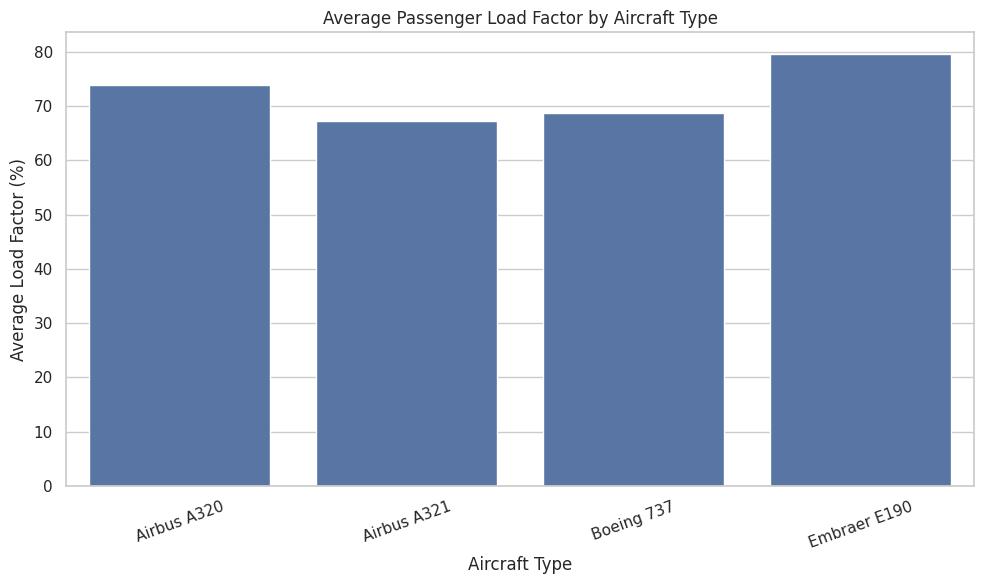

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=aircraft_summary,
    x='Aircraft_Type',
    y='Avg_Load_Factor'
)
plt.title('Average Passenger Load Factor by Aircraft Type')
plt.xlabel('Aircraft Type')
plt.ylabel('Average Load Factor (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 13. Visualisation 2 — Load Factor by Route

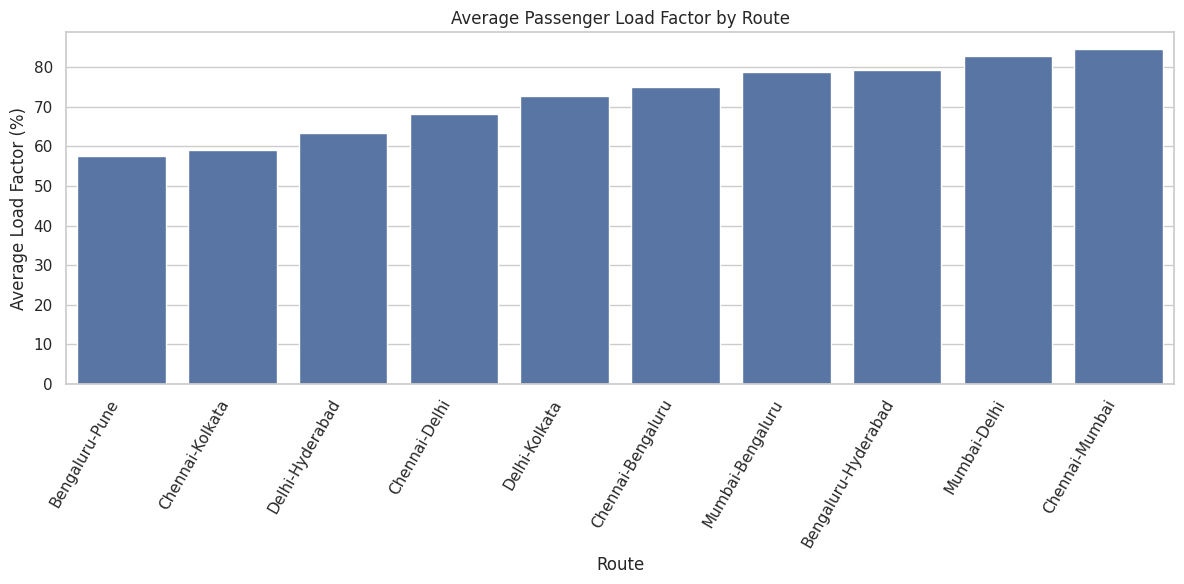

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=route_summary,
    x='Route',
    y='Avg_Load_Factor'
)
plt.title('Average Passenger Load Factor by Route')
plt.xlabel('Route')
plt.ylabel('Average Load Factor (%)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


## 14. Visualisation 3 — Route Distance vs Load Factor

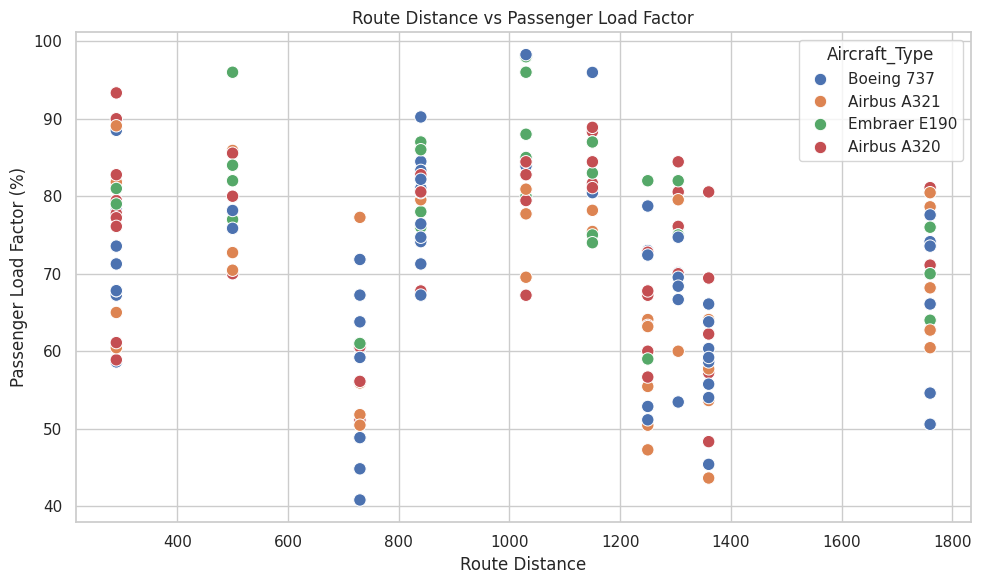

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Route_Distance',
    y='Load_Factor',
    hue='Aircraft_Type',
    s=80
)
plt.title('Route Distance vs Passenger Load Factor')
plt.xlabel('Route Distance')
plt.ylabel('Passenger Load Factor (%)')
plt.tight_layout()
plt.show()


## 15. Visualisation 4 — Flight Duration vs Turnaround Time

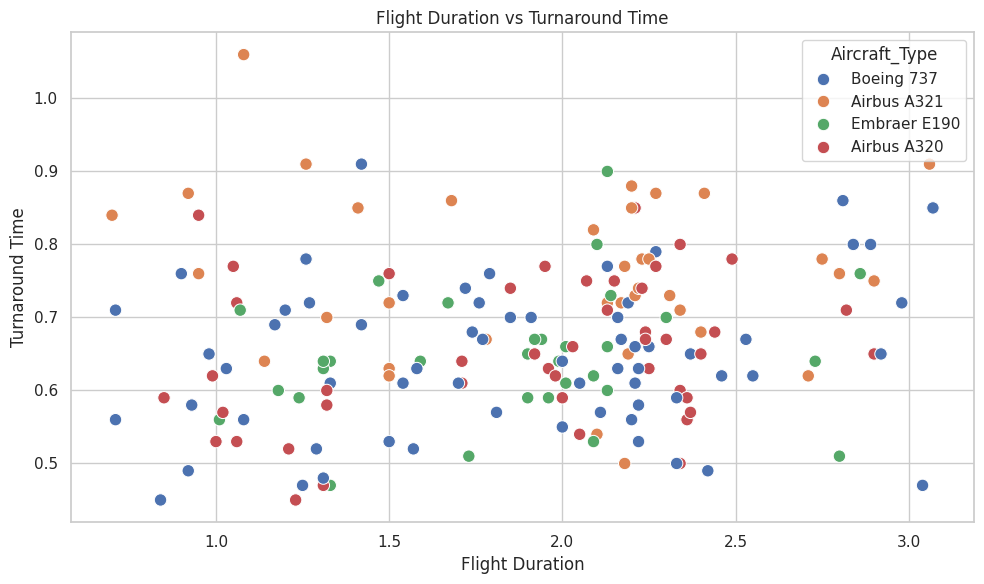

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Flight_Duration',
    y='Turnaround_Time',
    hue='Aircraft_Type',
    s=80
)
plt.title('Flight Duration vs Turnaround Time')
plt.xlabel('Flight Duration')
plt.ylabel('Turnaround Time')
plt.tight_layout()
plt.show()


## 16. Linear Regression Model

### Target
**Passenger Load Factor**

### Features
- Route Distance
- Flight Duration
- Turnaround Time
- Passenger Capacity


In [20]:
features = [
    'Route_Distance',
    'Flight_Duration',
    'Turnaround_Time',
    'Passenger_Capacity'
]

X = df[features]
y = df['Load_Factor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 144
Testing rows: 36


## 17. Train Linear Regression Model

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Intercept:", round(model.intercept_, 4))


Model trained successfully.
Intercept: 71.3205


## 18. Predictions

In [24]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual_Load_Factor': y_test.values,
    'Predicted_Load_Factor': y_pred
})

results.head(10).round(2)


,Actual_Load_Factor,Predicted_Load_Factor
0,64.09,64.57
1,70.00,65.85
2,69.54,67.21
3,75.45,64.89
4,67.24,73.21
5,54.60,68.23
6,67.24,75.32
7,82.78,73.07
8,56.67,72.08
9,60.00,72.79


## 19. Model Evaluation

In [25]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R² Score:", round(r2, 3))


Mean Absolute Error (MAE): 10.571
Root Mean Squared Error (RMSE): 12.483
R² Score: 0.128


## 20. Linear Regression Coefficients

In [ ]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

coefficients.round(4)


## 21. Actual vs Predicted Load Factor

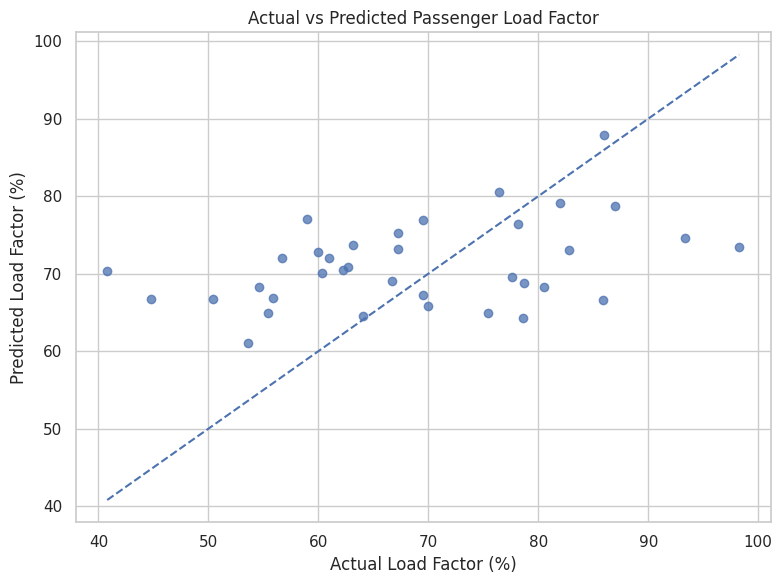

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.75)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Load Factor (%)')
plt.ylabel('Predicted Load Factor (%)')
plt.title('Actual vs Predicted Passenger Load Factor')
plt.tight_layout()
plt.show()


## 22. Key Insights

In [28]:
highest_aircraft = aircraft_summary.loc[
    aircraft_summary['Avg_Load_Factor'].idxmax()
]

lowest_aircraft = aircraft_summary.loc[
    aircraft_summary['Avg_Load_Factor'].idxmin()
]

lowest_route = route_summary.iloc[0]
highest_route = route_summary.iloc[-1]

print("1. Highest aircraft load factor:",
      highest_aircraft['Aircraft_Type'],
      "=", round(highest_aircraft['Avg_Load_Factor'], 2), "%")

print("2. Lowest aircraft load factor:",
      lowest_aircraft['Aircraft_Type'],
      "=", round(lowest_aircraft['Avg_Load_Factor'], 2), "%")

print("3. Lowest-occupancy route:",
      lowest_route['Route'],
      "=", round(lowest_route['Avg_Load_Factor'], 2), "%")

print("4. Highest-occupancy route:",
      highest_route['Route'],
      "=", round(highest_route['Avg_Load_Factor'], 2), "%")

print("5. Average fleet load factor:",
      round(df['Load_Factor'].mean(), 2), "%")

print("6. Distance-load factor correlation:",
      round(distance_load_corr, 3))

print("7. Linear Regression R²:",
      round(r2, 3))


1. Highest aircraft load factor: Embraer E190 = 79.61 %
2. Lowest aircraft load factor: Airbus A321 = 67.16 %
3. Lowest-occupancy route: Bengaluru-Pune = 57.47 %
4. Highest-occupancy route: Chennai-Mumbai = 84.62 %
5. Average fleet load factor: 71.62 %
6. Distance-load factor correlation: -0.207
7. Linear Regression R²: 0.128


## 23. Practical Action Plan

1. Review routes that consistently show low passenger load factors.
2. Evaluate whether aircraft capacity is appropriately matched to demand on low-occupancy routes.
3. Monitor aircraft types with relatively lower average load factors.
4. Investigate route-aircraft combinations with repeated low occupancy.
5. Consider passenger demand patterns when planning aircraft allocation and flight frequency.
6. Track turnaround time alongside flight duration to monitor operational efficiency.
7. Recalculate utilisation metrics regularly so fleet planning decisions use recent operating data.

**Note:** Actual fleet decisions should also consider revenue, operating cost, airport constraints, schedule connectivity and demand forecasts.


## 24. Conclusion

This analysis evaluates aircraft utilisation using passenger load factor, flight-time ratio, route-level occupancy and aircraft-level performance. Exploratory analysis identifies low-occupancy routes and potentially inefficient route-aircraft combinations. The Linear Regression model provides a quantitative relationship between selected operational variables and passenger load factor.

The analysis can support future fleet-planning decisions by helping management compare aircraft types, monitor route occupancy and identify areas requiring further operational investigation.
